# NEXARETAIL ORDERS ANALYSIS

# Importing required libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Improve chart appearance
sns.set_style("whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Load dataset

In [ ]:
df = pd.read_csv("P3_Dataset.csv")

In [ ]:
df.shape

(11875, 12)

# Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11875 entries, 0 to 11874
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_date     11875 non-null  object
 1   store_name     11875 non-null  object
 2   store_type     11875 non-null  object
 3   city           11875 non-null  object
 4   state          11875 non-null  object
 5   product_name   11875 non-null  object
 6   category       11875 non-null  object
 7   quantity       11875 non-null  int64 
 8   unit_price     11875 non-null  int64 
 9   total_amount   11875 non-null  int64 
 10  channel        11875 non-null  object
 11  return_reason  4443 non-null   object
dtypes: int64(3), object(9)
memory usage: 1.1+ MB


# Display column names

In [ ]:
df.columns

Index(['order_date', 'store_name', 'store_type', 'city', 'state',
       'product_name', 'category', 'quantity', 'unit_price', 'total_amount',
       'channel', 'return_reason'],
      dtype='object')

# Number of rows and columns

In [ ]:
print("Rows and Columns:", df.shape)

print("Rows:", df.shape[0])

print("Columns:", df.shape[1])

Rows and Columns: (11875, 12)
Rows: 11875
Columns: 12


# Missing values

In [ ]:
df.isnull().sum()

,0
order_date,0
store_name,0
store_type,0
city,0
state,0
product_name,0
category,0
quantity,0
unit_price,0
total_amount,0


# Missing value percentage

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent

,0
order_date,0.000000
store_name,0.000000
store_type,0.000000
city,0.000000
state,0.000000
product_name,0.000000
category,0.000000
quantity,0.000000
unit_price,0.000000
total_amount,0.000000


# Duplicate records


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


# Summary statistics for numerical columns

In [ ]:
df.describe()

,quantity,unit_price,total_amount
count,11875.000000,11875.000000,11875.000000
mean,20.436379,195.316211,4012.964211
std,11.540252,169.452667,4596.895645
min,1.000000,30.000000,30.000000
25%,10.000000,50.000000,900.000000
50%,20.000000,110.000000,2100.000000
75%,31.000000,280.000000,5320.000000
max,40.000000,550.000000,22000.000000


# Summary of categorical columns

In [ ]:
df.describe(include='object')

,order_date,store_name,store_type,city,state,product_name,category,channel,return_reason
count,11875,11875,11875,11875,11875,11875,11875,11875,4443
unique,336,40,2,10,2,21,8,2,3
top,2023-10-01,Big Bazaar Vadodara,Kirana,Kolhapur,Maharashtra,NexaCrunch Mixture 200g,Dal,Offline,Late Delivery
freq,61,327,8912,1254,7179,610,1736,8313,1507


# Convert order_date to datetime format

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

# UPDATED ORDER DATE COLUMN

In [ ]:
df['order_date'].head()

,order_date
0,2023-01-16
1,2023-01-28
2,2023-01-05
3,2023-01-13
4,2023-01-12


# Create Month Number


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['Month'] = df['order_date'].dt.month

df[['order_date','Month']].head()

,order_date,Month
0,2023-01-16,1
1,2023-01-28,1
2,2023-01-05,1
3,2023-01-13,1
4,2023-01-12,1


# Weekday

In [ ]:
df['Weekday'] = df['order_date'].dt.day_name()

df[['order_date','Weekday']].head()

,order_date,Weekday
0,2023-01-16,Monday
1,2023-01-28,Saturday
2,2023-01-05,Thursday
3,2023-01-13,Friday
4,2023-01-12,Thursday


# Week Number

In [ ]:
df['Week_Number'] = df['order_date'].dt.isocalendar().week

df[['order_date','Week_Number']].head()

,order_date,Week_Number
0,2023-01-16,3
1,2023-01-28,4
2,2023-01-05,1
3,2023-01-13,2
4,2023-01-12,2


# Create Return Status

In [ ]:
import numpy as np
df['Return_Status'] = np.where(
    df['return_reason'].isnull(),
    'No Return',
    'Returned'
)

df[['return_reason','Return_Status']].head(10)

,return_reason,Return_Status
0,NaN,No Return
1,NaN,No Return
2,NaN,No Return
3,NaN,No Return
4,Late Delivery,Returned
5,Late Delivery,Returned
6,NaN,No Return
7,NaN,No Return
8,Late Delivery,Returned
9,NaN,No Return


# Verify new data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11875 entries, 0 to 11874
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_date     11875 non-null  datetime64[ns]
 1   store_name     11875 non-null  object        
 2   store_type     11875 non-null  object        
 3   city           11875 non-null  object        
 4   state          11875 non-null  object        
 5   product_name   11875 non-null  object        
 6   category       11875 non-null  object        
 7   quantity       11875 non-null  int64         
 8   unit_price     11875 non-null  int64         
 9   total_amount   11875 non-null  int64         
 10  channel        11875 non-null  object        
 11  return_reason  4443 non-null   object        
 12  Month          11875 non-null  int32         
 13  Return_Status  11875 non-null  object        
dtypes: datetime64[ns](1), int32(1), int64(3), object(9)
memory usage: 1.2+

# Display first five rows

In [ ]:
df.head()

,order_date,store_name,store_type,city,state,product_name,category,quantity,unit_price,total_amount,channel,return_reason,Month,Return_Status
0,2023-01-16,Sharma Kirana,Kirana,Kolhapur,Maharashtra,NexaGold Wheat Atta 10kg,Atta,36,140,5040,Offline,NaN,1,No Return
1,2023-01-28,Patil General,Kirana,Pune,Maharashtra,NexaGold Toor Dal 1kg,Dal,15,50,750,Online,NaN,1,No Return
2,2023-01-05,Patel Kirana,Kirana,Rajkot,Gujarat,NexaGold Sunflower Oil 5L,Edible Oil,4,140,560,Offline,NaN,1,No Return
3,2023-01-13,Thakur Traders,Kirana,Nagpur,Maharashtra,NexaCrunch Mixture 200g,Snacks,15,50,750,Offline,NaN,1,No Return
4,2023-01-12,Reliance Fresh Baner,Supermarket,Pune,Maharashtra,NexaClean Dishwash 500ml,Household,6,110,660,Offline,Late Delivery,1,Returned


# Revenue by City

/tmp/ipykernel_1610/1548148344.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


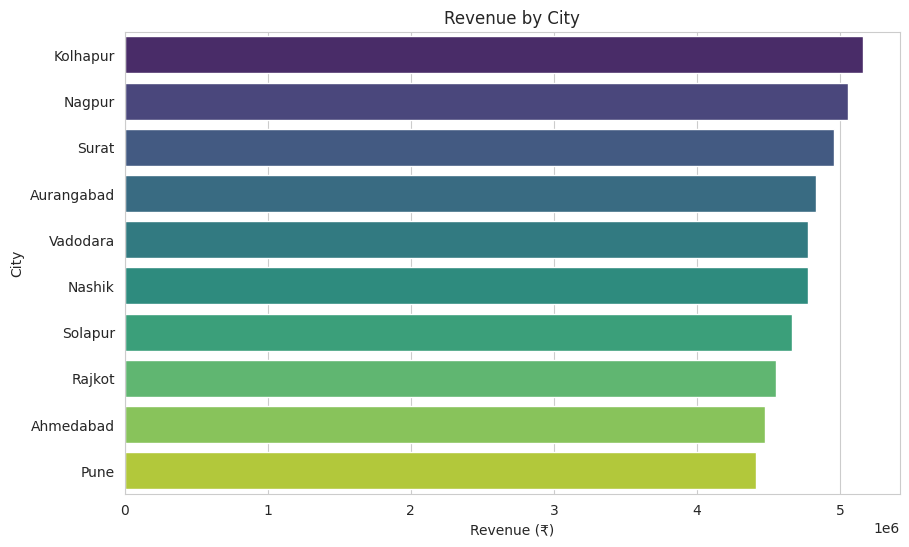

,total_amount
city,
Kolhapur,5157800
Nagpur,5055540
Surat,4958680
Aurangabad,4831770
Vadodara,4778070
Nashik,4773550
Solapur,4663150
Rajkot,4552270
Ahmedabad,4472620


In [ ]:
city_sales = df.groupby('city')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index,
    palette='viridis'
)

plt.title("Revenue by City")
plt.xlabel("Revenue (₹)")
plt.ylabel("City")

plt.show()

city_sales

/tmp/ipykernel_1610/2946103212.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


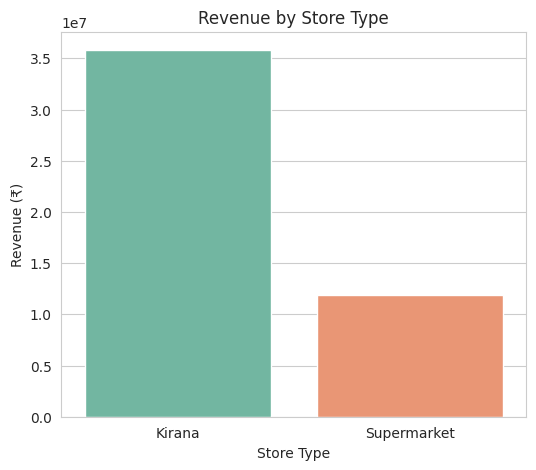

,total_amount
store_type,
Kirana,35807170
Supermarket,11846780


In [ ]:
store_sales = df.groupby('store_type')['total_amount'].sum()

plt.figure(figsize=(6,5))

sns.barplot(
    x=store_sales.index,
    y=store_sales.values,
    palette='Set2'
)

plt.title("Revenue by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Revenue (₹)")

plt.show()

store_sales

/tmp/ipykernel_1610/1356488176.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


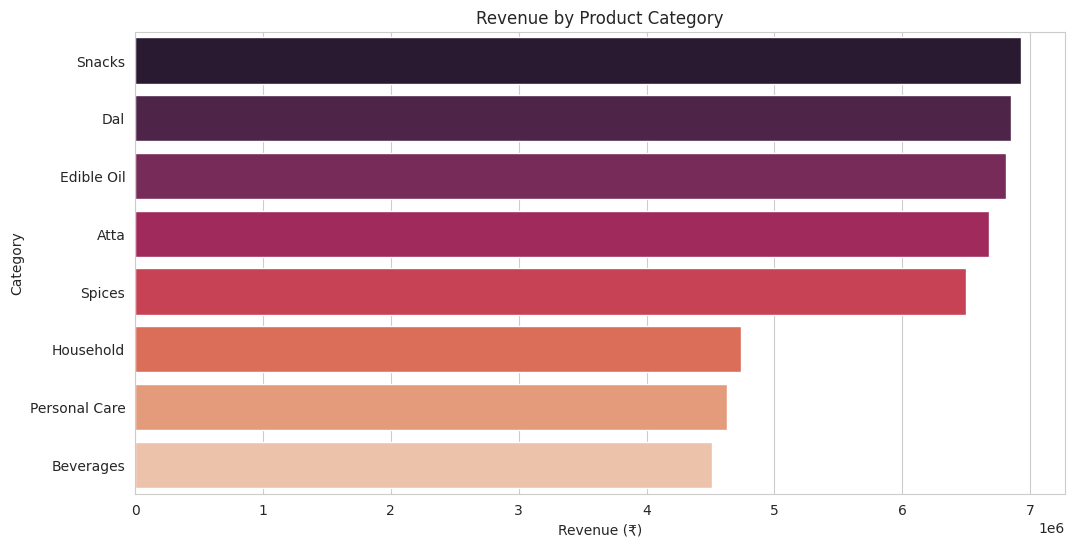

,total_amount
category,
Snacks,6926430
Dal,6851770
Edible Oil,6811800
Atta,6678890
Spices,6497960
Household,4738970
Personal Care,4632780
Beverages,4515350


In [ ]:
category_sales = (
    df.groupby('category')['total_amount']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index,
    palette='rocket'
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue (₹)")
plt.ylabel("Category")

plt.show()

category_sales

/tmp/ipykernel_1610/1247835547.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


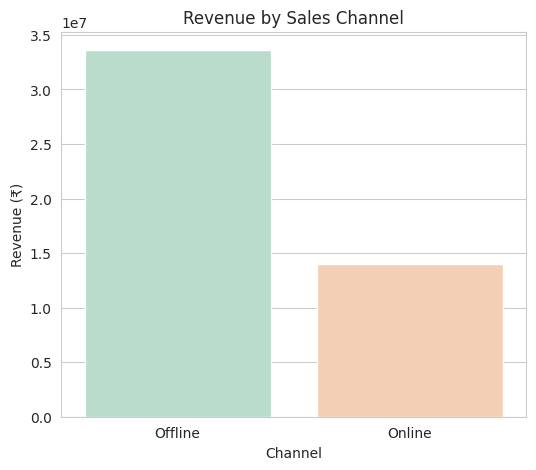

,total_amount
channel,
Offline,33612590
Online,14041360


In [ ]:
channel_sales = df.groupby('channel')['total_amount'].sum()

plt.figure(figsize=(6,5))

sns.barplot(
    x=channel_sales.index,
    y=channel_sales.values,
    palette='Pastel2'
)

plt.title("Revenue by Sales Channel")
plt.xlabel("Channel")
plt.ylabel("Revenue (₹)")

plt.show()

channel_sales

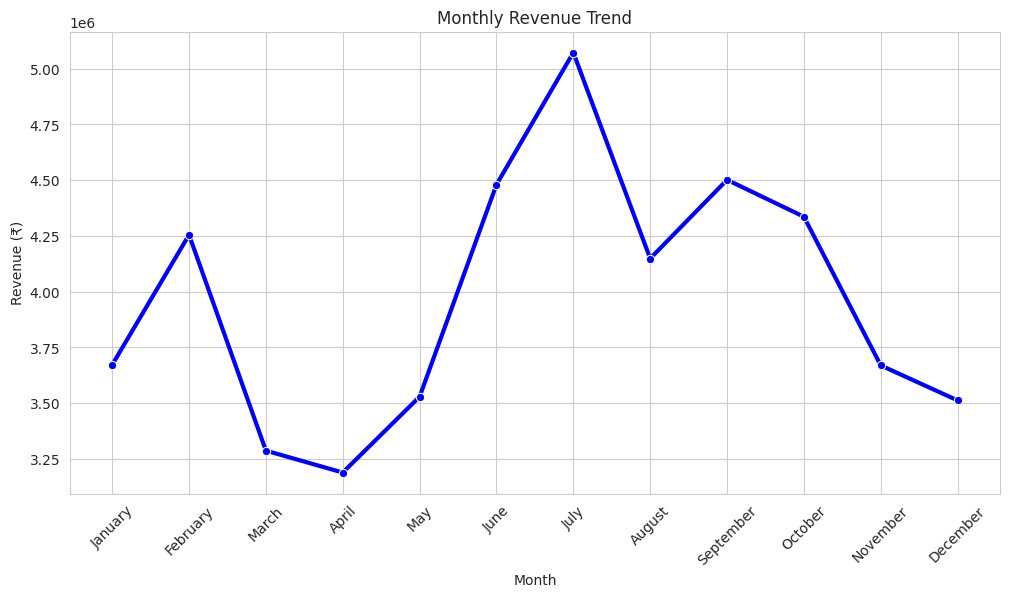

,total_amount
Month_Name,
January,3671930
February,4255000
March,3287310
April,3189090
May,3529240
June,4480260
July,5072420
August,4148900
September,4501790


In [ ]:
df['Month_Name'] = df['order_date'].dt.month_name()

monthly_sales = (
    df.groupby('Month_Name')['total_amount']
      .sum()
      .reindex([
          'January','February','March','April',
          'May','June','July','August',
          'September','October','November','December'
      ])
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o',
    linewidth=3,
    color='blue'
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")

plt.grid(True)

plt.show()

monthly_sales

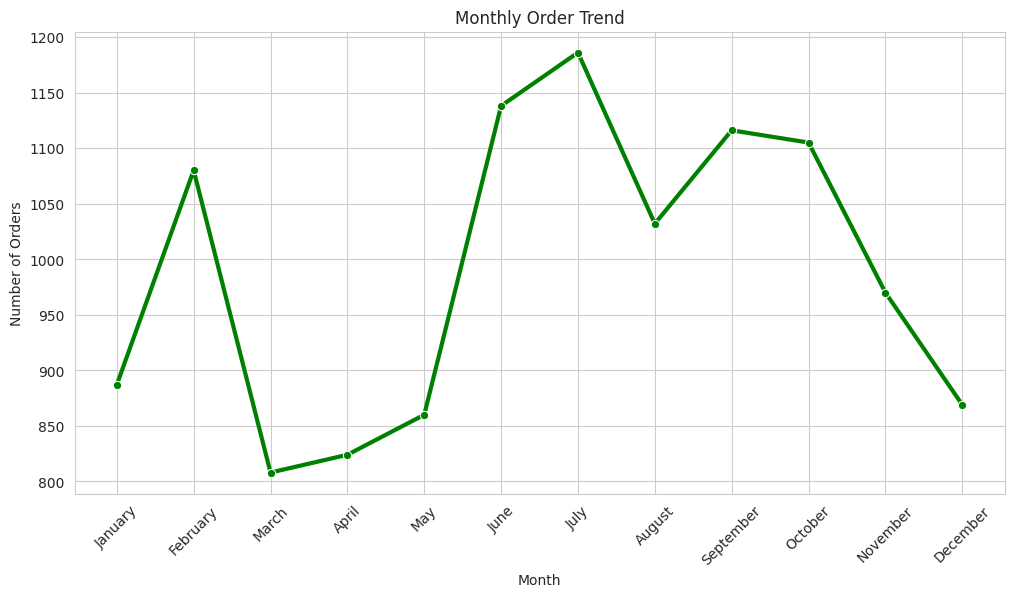

,0
Month_Name,
January,887
February,1080
March,808
April,824
May,860
June,1138
July,1186
August,1032
September,1116


In [ ]:
monthly_orders = (
    df.groupby('Month_Name')
      .size()
      .reindex([
          'January','February','March','April',
          'May','June','July','August',
          'September','October','November','December'
      ])
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_orders.index,
    y=monthly_orders.values,
    marker='o',
    linewidth=3,
    color='green'
)

plt.xticks(rotation=45)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.grid(True)

plt.show()

monthly_orders

/tmp/ipykernel_1610/3753563962.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


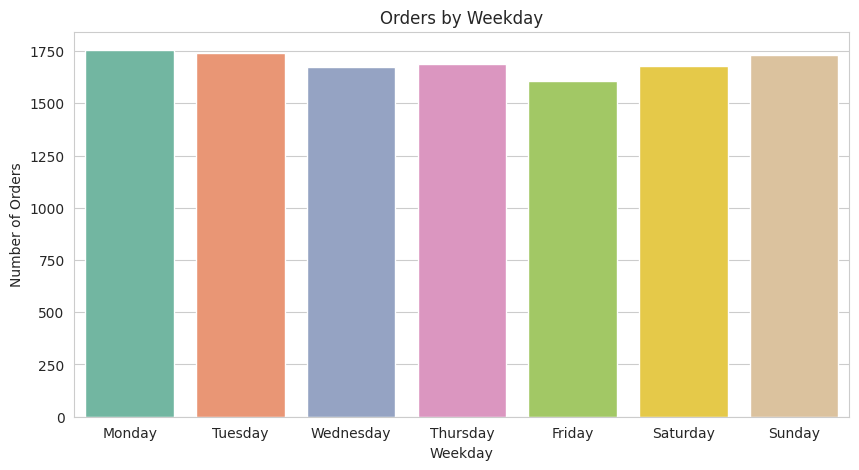

,0
Weekday,
Monday,1755
Tuesday,1740
Wednesday,1673
Thursday,1689
Friday,1608
Saturday,1680
Sunday,1730


In [ ]:
df['Weekday'] = df['order_date'].dt.day_name()
weekday_orders = (
    df.groupby('Weekday')
      .size()
      .reindex(
          ['Monday',
          'Tuesday',
          'Wednesday',
          'Thursday',
          'Friday',
          'Saturday',
          'Sunday'
      ])
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=weekday_orders.index,
    y=weekday_orders.values,
    palette='Set2'
)

plt.title("Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")

plt.show()

weekday_orders

/tmp/ipykernel_1610/275398950.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


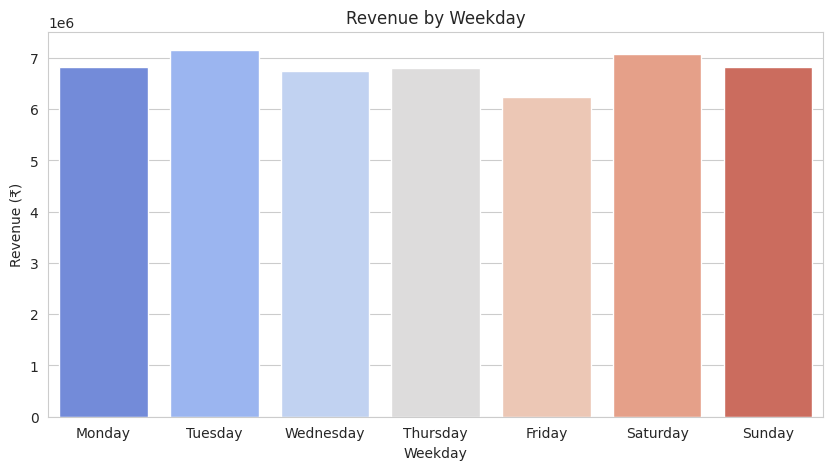

In [ ]:
weekday_sales = (
    df.groupby('Weekday')['total_amount']
      .sum()
      .reindex([
          'Monday',
          'Tuesday',
          'Wednesday',
          'Thursday',
          'Friday',
          'Saturday',
          'Sunday'
      ])
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values,
    palette='coolwarm'
)

plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue (₹)")

plt.show()

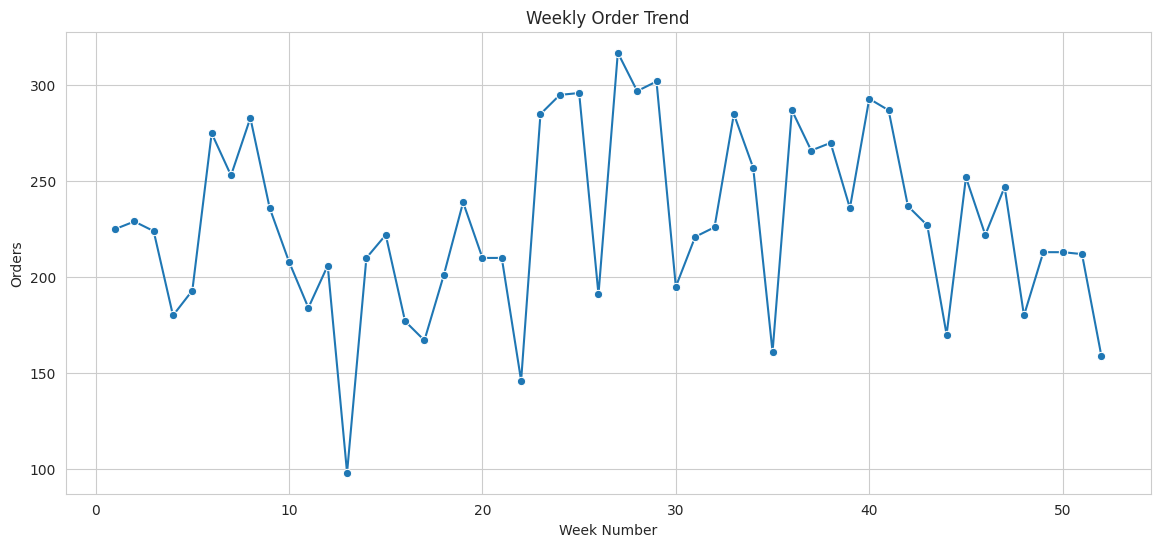

In [ ]:
df['Week_Number'] = df['order_date'].dt.isocalendar().week
weekly_orders = (
    df.groupby('Week_Number')
      .size()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    x=weekly_orders.index,
    y=weekly_orders.values,
    marker='o'
)

plt.title("Weekly Order Trend")
plt.xlabel("Week Number")
plt.ylabel("Orders")

plt.grid(True)

plt.show()

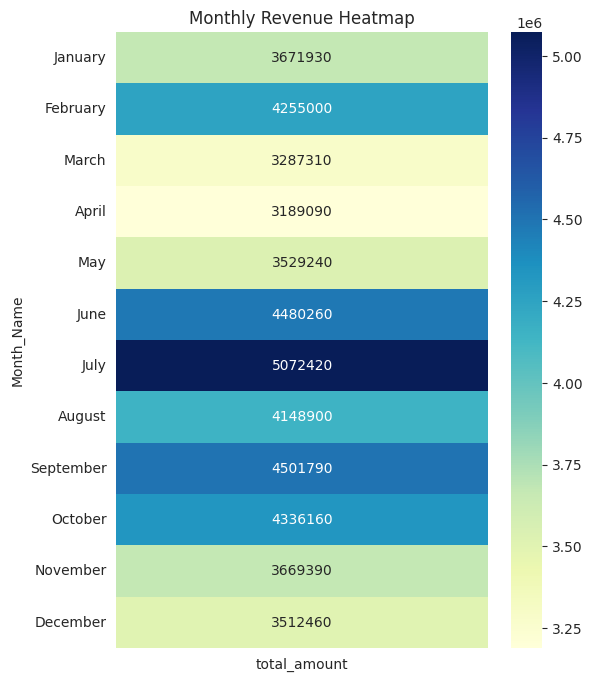

In [ ]:
monthly_heatmap = (
    df.groupby('Month_Name')['total_amount']
      .sum()
      .reindex([
          'January','February','March','April',
          'May','June','July','August',
          'September','October','November','December'
      ])
      .to_frame()
)

plt.figure(figsize=(6,8))

sns.heatmap(
    monthly_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Monthly Revenue Heatmap")

plt.show()

In [ ]:
# Overall Return Rate

total_orders = len(df)

returned_orders = len(df[df['Return_Status'] == 'Returned'])

return_rate = (returned_orders / total_orders) * 100

print("Total Orders :", total_orders)
print("Returned Orders :", returned_orders)
print("Return Rate : {:.2f}%".format(return_rate))

/tmp/ipykernel_1269/3114325136.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


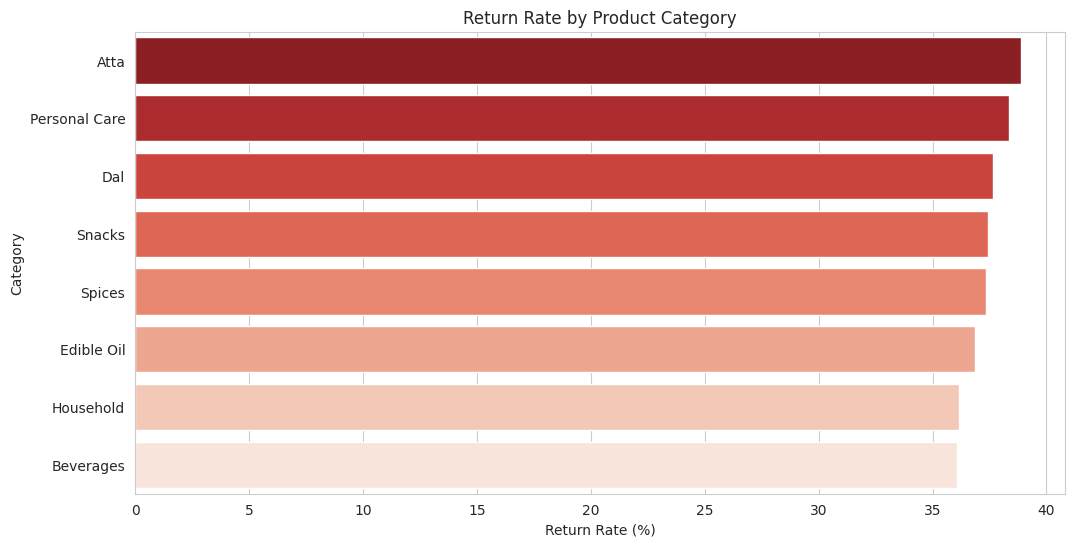

,Return_Status
category,
Atta,38.872404
Personal Care,38.352524
Dal,37.672811
Snacks,37.434095
Spices,37.341390
Edible Oil,36.879857
Household,36.148649
Beverages,36.075949


In [ ]:
# Return Rate by Category

category_return = (
    df.groupby('category')['Return_Status']
      .apply(lambda x: (x == 'Returned').mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_return.values,
    y=category_return.index,
    palette='Reds_r'
)

plt.title("Return Rate by Product Category")
plt.xlabel("Return Rate (%)")
plt.ylabel("Category")

plt.show()

category_return

/tmp/ipykernel_1610/3641736495.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


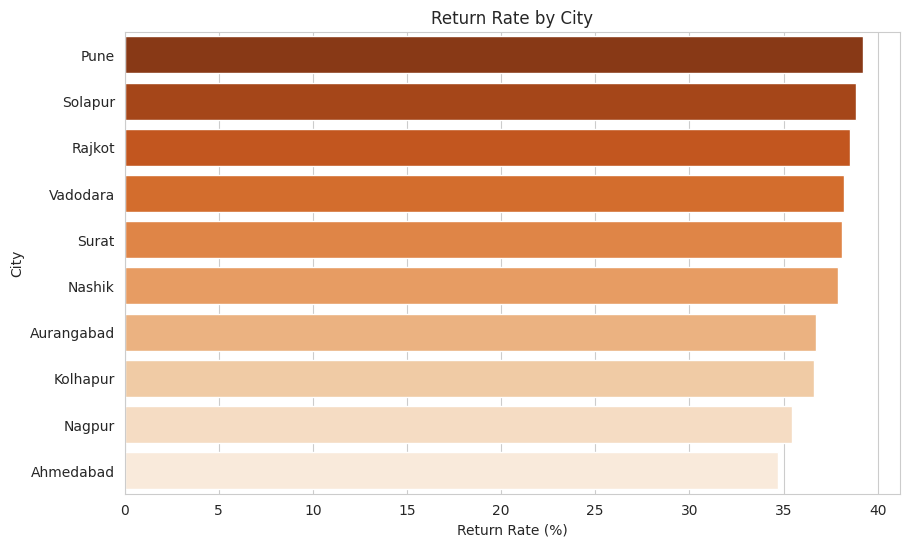

,Return_Status
city,
Pune,39.201452
Solapur,38.833333
Rajkot,38.521066
Vadodara,38.196721
Surat,38.119658
Nashik,37.869822
Aurangabad,36.747967
Kolhapur,36.602871
Nagpur,35.454545


In [ ]:
city_return = (
    df.groupby('city')['Return_Status']
      .apply(lambda x: (x == 'Returned').mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=city_return.values,
    y=city_return.index,
    palette='Oranges_r'
)

plt.title("Return Rate by City")
plt.xlabel("Return Rate (%)")
plt.ylabel("City")

plt.show()

city_return

/tmp/ipykernel_1610/923096016.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


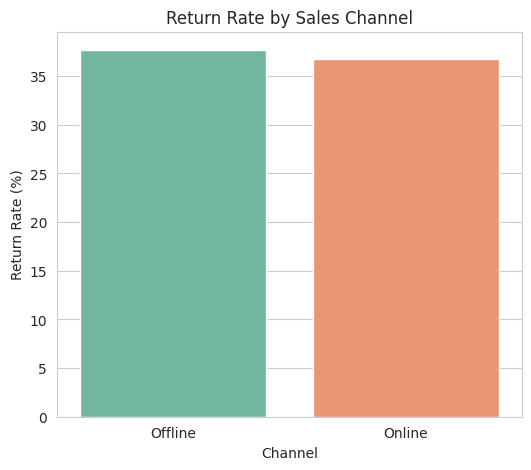

,Return_Status
channel,
Offline,37.687959
Online,36.777092


In [ ]:
channel_return = (
    df.groupby('channel')['Return_Status']
      .apply(lambda x: (x == 'Returned').mean() * 100)
)

plt.figure(figsize=(6,5))

sns.barplot(
    x=channel_return.index,
    y=channel_return.values,
    palette='Set2'
)

plt.title("Return Rate by Sales Channel")
plt.xlabel("Channel")
plt.ylabel("Return Rate (%)")

plt.show()

channel_return

/tmp/ipykernel_1269/1025898200.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


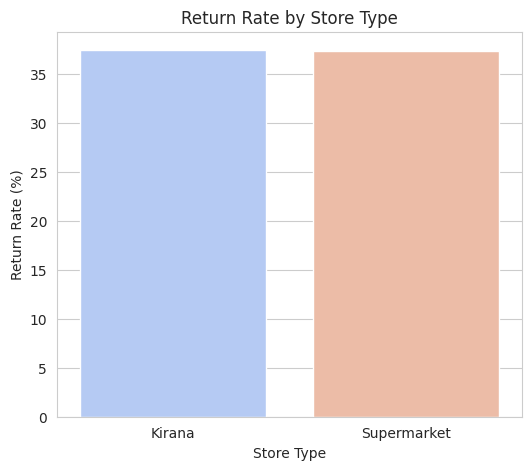

,Return_Status
store_type,
Kirana,37.432675
Supermarket,37.360783


In [ ]:
store_return = (
    df.groupby('store_type')['Return_Status']
      .apply(lambda x: (x == 'Returned').mean() * 100)
)

plt.figure(figsize=(6,5))

sns.barplot(
    x=store_return.index,
    y=store_return.values,
    palette='coolwarm'
)

plt.title("Return Rate by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Return Rate (%)")

plt.show()

store_return

/tmp/ipykernel_1610/927119098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


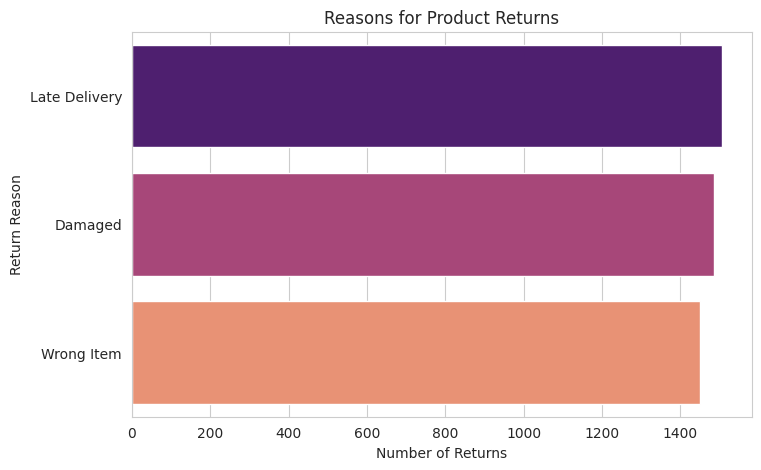

,count
return_reason,
Late Delivery,1507
Damaged,1486
Wrong Item,1450


In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y='return_reason',
    order=df['return_reason'].value_counts().index,
    palette='magma'
)

plt.title("Reasons for Product Returns")
plt.xlabel("Number of Returns")
plt.ylabel("Return Reason")

plt.show()

df['return_reason'].value_counts()

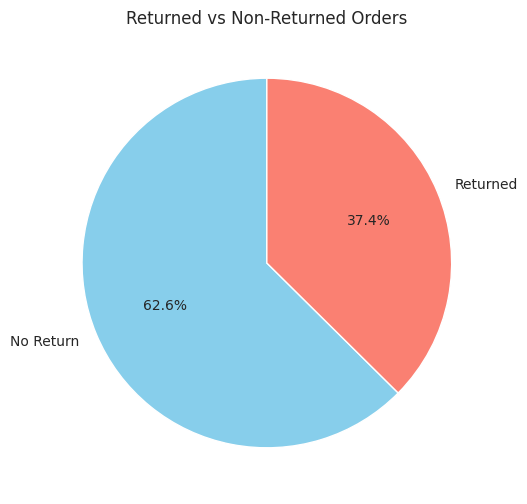

In [ ]:
plt.figure(figsize=(6,6))

df['Return_Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'salmon']
)

plt.title("Returned vs Non-Returned Orders")
plt.ylabel("")

plt.show()

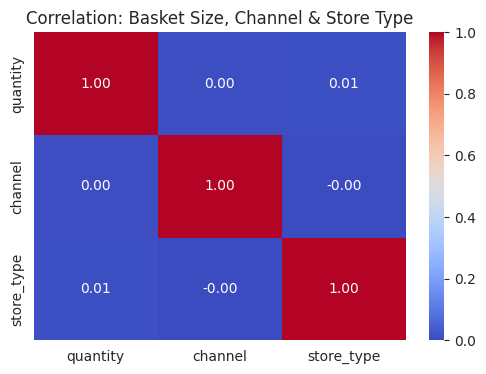

,quantity,channel,store_type
quantity,1.000000,0.003689,0.010203
channel,0.003689,1.000000,-0.000329
store_type,0.010203,-0.000329,1.000000


In [ ]:
# Encode categorical variables

corr_df = df.copy()

corr_df['channel'] = corr_df['channel'].map({
    'Offline': 0,
    'Online': 1
})

corr_df['store_type'] = corr_df['store_type'].map({
    'Kirana': 0,
    'Supermarket': 1
})

# Correlation Matrix

corr = corr_df[['quantity', 'channel', 'store_type']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation: Basket Size, Channel & Store Type")

plt.show()

corr